# Cell-Cell Communication Analysis
Infer ligand-receptor interactions between spatially proximal cell types. Map signaling pathways active at tumor-immune interfaces and identify therapeutic targets.

In [1]:
# IMPORTS & PATHS
from __future__ import annotations
from pathlib import Path
import warnings, os, tempfile
warnings.filterwarnings('ignore')
os.environ.setdefault('NUMBA_CACHE_DIR',
    str(Path(tempfile.gettempdir()) / 'numba_cache'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
from itertools import combinations
import scanpy as sc
import squidpy as sq

rcParams['font.family'] = 'DejaVu Sans'
sc.settings.verbosity  = 3

cwd = Path.cwd().resolve()
if (cwd / 'README.md').exists() and (cwd / 'data').exists():
    project_root = cwd
elif (cwd.parent / 'README.md').exists():
    project_root = cwd.parent
else:
    raise RuntimeError(f'Cannot locate project root from cwd={cwd}.')

processed_dir = project_root / 'data'    / 'processed'
fig_cc_dir    = project_root / 'figures' / 'cellcomm'
fig_cc_dir.mkdir(parents=True, exist_ok=True)
sc.settings.figdir = str(fig_cc_dir)

print(f'Scanpy  : {sc.__version__}')
print(f'Squidpy : {sq.__version__}')

Scanpy  : 1.12
Squidpy : 1.8.1


In [2]:
# LOAD ADATA
adata = sc.read_h5ad(processed_dir / 'adata_scored.h5ad')

print(adata)
print(f'\nSpots      : {adata.n_obs:,}')
print(f'Genes      : {adata.n_vars:,}')
print(f'Cell types : {adata.obs["cell_type"].nunique()}')
print(f'\nCell type counts:')
print(adata.obs['cell_type'].value_counts())

AnnData object with n_obs × n_vars = 4869 × 21349
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'leiden_0.3', 'leiden_0.5', 'leiden_0.6', 'leiden_1.0', 'leiden', 'cell_type', 'score_Tumor_Epithelial', 'score_Luminal_A', 'score_HER2_Enriched', 'score_Basal_Like', 'score_Proliferating', 'score_CAFs', 'score_Myofibroblasts', 'score_Endothelial', 'score_Adipocytes', 'score_T_Cells', 'score_CD8_T_Cells', 'score_CD4_T_Cells', 'score_Tregs', 'score_B_Cells', 'score_Plasma_Cells', 'score_Macrophages_M1', 'score_Macrophages_M2', 'score_NK_Cells', 'score_Mast_Cells', 'score_Dendritic_Cells', 'score_TLS_signature', 'score_Hypoxia', 'score_EMT', 'score_Exhausted_T'
    var:

In [3]:
# DEFINE LR PAIRS — COMPLETE TME
# Source: CellChatDB + NicheNet + literature

lr_pairs = {
    # Immune Checkpoint (Tumor -> Immune)
    'PD-L1 -> PD-1'        : ('CD274',   'PDCD1'),
    'CD80 -> CTLA4'        : ('CD80',    'CTLA4'),
    'CD86 -> CTLA4'        : ('CD86',    'CTLA4'),
    'TIGIT -> CD155'       : ('TIGIT',   'PVR'),
    'LAG3 -> MHC-II'       : ('LAG3',    'HLA-DRA'),

    # TGF-beta Axis (CAF -> Tumor/Immune)
    'TGFb1 -> TGFBR1'     : ('TGFB1',   'TGFBR1'),
    'TGFb1 -> TGFBR2'     : ('TGFB1',   'TGFBR2'),
    'TGFb2 -> TGFBR2'     : ('TGFB2',   'TGFBR2'),

    # VEGF / Angiogenesis (Tumor -> Endothelial)
    'VEGFA -> KDR'         : ('VEGFA',   'KDR'),
    'VEGFA -> FLT1'        : ('VEGFA',   'FLT1'),
    'VEGFC -> FLT4'        : ('VEGFC',   'FLT4'),

    # Immune Recruitment Chemokines
    'CXCL9 -> CXCR3'      : ('CXCL9',   'CXCR3'),
    'CXCL10 -> CXCR3'     : ('CXCL10',  'CXCR3'),
    'CXCL12 -> CXCR4'     : ('CXCL12',  'CXCR4'),
    'CXCL13 -> CXCR5'     : ('CXCL13',  'CXCR5'),
    'CCL2 -> CCR2'         : ('CCL2',    'CCR2'),
    'CCL5 -> CCR5'         : ('CCL5',    'CCR5'),
    'CCL19 -> CCR7'        : ('CCL19',   'CCR7'),

    # TNF / Inflammatory
    'TNF -> TNFRSF1A'      : ('TNF',     'TNFRSF1A'),
    'FASL -> FAS'          : ('FASLG',   'FAS'),
    'TRAIL -> DR4'         : ('TNFSF10', 'TNFRSF10A'),

    # Notch (Stroma -> Tumor)
    'JAG1 -> NOTCH1'       : ('JAG1',    'NOTCH1'),
    'JAG1 -> NOTCH2'       : ('JAG1',    'NOTCH2'),
    'DLL4 -> NOTCH1'       : ('DLL4',    'NOTCH1'),

    # WNT (Tumor autocrine)
    'WNT5A -> FZD1'        : ('WNT5A',   'FZD1'),
    'WNT5A -> ROR2'        : ('WNT5A',   'ROR2'),

    # EGF / HER2 (Tumor autocrine)
    'EGF -> EGFR'          : ('EGF',     'EGFR'),
    'EREG -> EGFR'         : ('EREG',    'EGFR'),
    'NRG1 -> ERBB3'        : ('NRG1',    'ERBB3'),

    # ECM / Adhesion (CAF -> Tumor)
    'FN1 -> ITGA5'         : ('FN1',     'ITGA5'),
    'FN1 -> ITGB1'         : ('FN1',     'ITGB1'),
    'COL1A1 -> ITGA1'      : ('COL1A1',  'ITGA1'),
    'POSTN -> ITGAV'       : ('POSTN',   'ITGAV'),

    # IL signaling (Immune -> Tumor)
    'IL6 -> IL6R'          : ('IL6',     'IL6R'),
    'IL10 -> IL10RA'       : ('IL10',    'IL10RA'),
    'IL1B -> IL1R1'        : ('IL1B',    'IL1R1'),
    'IFNG -> IFNGR1'       : ('IFNG',    'IFNGR1'),

    # MHC / Antigen Presentation
    'HLA-A -> CD8A'        : ('HLA-A',   'CD8A'),
    'HLA-DRA -> CD4'       : ('HLA-DRA', 'CD4'),
}

print(f'Total LR pairs defined : {len(lr_pairs)}')
print(f'\nGene availability:')
available, missing = [], []
for name, (lig, rec) in lr_pairs.items():
    l_ok = lig in adata.var_names
    r_ok = rec in adata.var_names
    if l_ok and r_ok:
        available.append(name)
    else:
        missing.append(f"{name}  ({'L missing' if not l_ok else 'R missing'})")

print(f'  Available : {len(available)}')
print(f'  Missing   : {len(missing)}')
if missing:
    for m in missing:
        print(f'    !  {m}')

Total LR pairs defined : 39

Gene availability:
  Available : 39
  Missing   : 0


In [4]:
# COMPUTE LR CO-EXPRESSION SCORES
# Geometric mean of ligand x receptor per spot
# then averaged per cluster

print('Computing LR co-expression scores...')
results = []

for name, (lig, rec) in lr_pairs.items():
    if lig not in adata.var_names or rec not in adata.var_names:
        continue

    lig_expr = np.array(adata.raw[:, lig].X.todense()).flatten() \
               if hasattr(adata.raw.X, 'todense') \
               else adata.raw[:, lig].X.flatten()
    rec_expr = np.array(adata.raw[:, rec].X.todense()).flatten() \
               if hasattr(adata.raw.X, 'todense') \
               else adata.raw[:, rec].X.flatten()

    lr_score = np.sqrt(lig_expr * rec_expr)
    adata.obs[f'lr_{name}'] = lr_score

    for ct in adata.obs['cell_type'].unique():
        mask  = adata.obs['cell_type'] == ct
        score = lr_score[mask.values].mean()
        results.append({
            'LR_pair'  : name,
            'Ligand'   : lig,
            'Receptor' : rec,
            'Cell_type': ct,
            'Score'    : score
        })

lr_df = pd.DataFrame(results)
print(f'   Computed {len(available)} LR pair scores')
print(f'   Results shape : {lr_df.shape}')
print(f'\nTop 10 LR interactions by mean score:')
top10 = lr_df.groupby('LR_pair')['Score'].mean() \
             .sort_values(ascending=False).head(10)
print(top10.round(4))

Computing LR co-expression scores...
   Computed 39 LR pair scores
   Results shape : (429, 5)

Top 10 LR interactions by mean score:
LR_pair
FN1 -> ITGB1       0.9797
HLA-DRA -> CD4     0.3350
FN1 -> ITGA5       0.3186
POSTN -> ITGAV     0.2596
COL1A1 -> ITGA1    0.1696
LAG3 -> MHC-II     0.1663
HLA-A -> CD8A      0.1451
CXCL12 -> CXCR4    0.1043
TGFb1 -> TGFBR2    0.0634
TGFb1 -> TGFBR1    0.0545
Name: Score, dtype: float32


In [5]:
# DUAL BARRIER STORY — TOP SIGNALS PER KEY CLUSTER

print('\n' + '='*60)
print('  DUAL IMMUNOSUPPRESSIVE BARRIER ANALYSIS')
print('='*60)

key_clusters = {
    'TGF-beta Source'       : 'Stromal Barrier (MGP+)',
    'Immune Exclusion Zone' : 'Macrophages / APC (CD74+)',
    'Tumour Core (PD-L1)'   : 'ER+ Invasive Carcinoma (GATA3+)',
}

for story_role, cluster_name in key_clusters.items():
    if cluster_name not in lr_df['Cell_type'].unique():
        print(f'\n! Cluster not found: {cluster_name}')
        continue

    top_signals = lr_df[lr_df['Cell_type'] == cluster_name] \
                  .sort_values('Score', ascending=False).head(10)

    print(f'\n--- {story_role.upper()} ---')
    print(f'    Cluster: {cluster_name}')
    print(f'    {"LR Pair":<25} {"Score":>8}')
    print(f'    {"-"*35}')
    for _, row in top_signals.iterrows():
        print(f'    {row["LR_pair"]:<25} {row["Score"]:>8.4f}')

print('\n' + '='*60)
print('  CHECKPOINT AND TGF-beta SCORES AT IMMUNE BOUNDARY')
print('='*60)

barrier_pairs = [
    'PD-L1 -> PD-1',
    'CD80 -> CTLA4',
    'LAG3 -> MHC-II',
    'TGFb1 -> TGFBR1',
    'TGFb1 -> TGFBR2',
    'CXCL13 -> CXCR5',
]

boundary_cluster = 'Macrophages / APC (CD74+)'
print(f'\n  Cluster: {boundary_cluster}')
print(f'  {"LR Pair":<25} {"Score":>8}  {"Pathway"}')
print(f'  {"-"*55}')

for pair in barrier_pairs:
    row = lr_df[
        (lr_df['LR_pair']   == pair) &
        (lr_df['Cell_type'] == boundary_cluster)
    ]
    if not row.empty:
        score   = row['Score'].values[0]
        pathway = (
            'CHECKPOINT'   if any(x in pair for x in ['PD','CTLA','LAG'])
            else 'TGF-beta BARRIER' if 'TGF' in pair
            else 'TLS SIGNAL'
        )
        print(f'  {pair:<25} {score:>8.4f}  {pathway}')

print('\n  Interpretation:')
print('  High checkpoint scores = PD-L1 suppressing T cells at boundary')
print('  High TGF-beta scores   = fibroblast barrier blocking migration')
print('  High CXCL13 score      = TLS recruitment confirmed')
print('='*60)


  DUAL IMMUNOSUPPRESSIVE BARRIER ANALYSIS

--- TGF-BETA SOURCE ---
    Cluster: Stromal Barrier (MGP+)
    LR Pair                      Score
    -----------------------------------
    FN1 -> ITGB1                1.0569
    FN1 -> ITGA5                0.2955
    POSTN -> ITGAV              0.2565
    HLA-DRA -> CD4              0.1768
    COL1A1 -> ITGA1             0.1679
    LAG3 -> MHC-II              0.1033
    TNF -> TNFRSF1A             0.0767
    HLA-A -> CD8A               0.0753
    IL1B -> IL1R1               0.0583
    TGFb1 -> TGFBR1             0.0583

--- IMMUNE EXCLUSION ZONE ---
    Cluster: Macrophages / APC (CD74+)
    LR Pair                      Score
    -----------------------------------
    HLA-DRA -> CD4              1.1669
    FN1 -> ITGB1                1.1223
    CXCL12 -> CXCR4             0.5557
    POSTN -> ITGAV              0.5122
    LAG3 -> MHC-II              0.4998
    HLA-A -> CD8A               0.4954
    FN1 -> ITGA5                0.4764
    C

In [15]:
# KEY BARRIER SCORES — REPORTING

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 50)

print('\n' + '='*55)
print('  KEY LIGAND-RECEPTOR SCORES — DUAL BARRIER EVIDENCE')
print('='*55)

key_pairs = [
    'PD-L1 -> PD-1',    # Lock 1 checkpoint
    'CD80 -> CTLA4',     # Lock 1 checkpoint
    'LAG3 -> MHC-II',    # Lock 1 checkpoint
    'TGFb1 -> TGFBR1',  # Lock 2 TGF-beta
    'TGFb1 -> TGFBR2',  # Lock 2 TGF-beta
    'TGFb2 -> TGFBR2',  # Lock 2 TGF-beta
    'FN1 -> ITGB1',      # ECM physical wall
    'COL1A1 -> ITGA1',   # ECM physical wall
    'CXCL13 -> CXCR5',  # TLS recruitment
    'CXCL12 -> CXCR4',  # TLS immune recruitment
]

key_clusters_report = [
    'ER+ Invasive Carcinoma (GATA3+)',
    'Macrophages / APC (CD74+)',
    'Stromal Barrier (MGP+)',
    'Plasma Cells / TLS (IGLC2+)',
]

summary_rows = []
for pair in key_pairs:
    for cluster in key_clusters_report:
        row = lr_df[
            (lr_df['LR_pair']   == pair) &
            (lr_df['Cell_type'] == cluster)
        ]
        if not row.empty:
            summary_rows.append({
                'LR Pair' : pair,
                'Cluster' : cluster,
                'Score'   : round(row['Score'].values[0], 4),
                'Pathway' : (
                    'CHECKPOINT' if any(x in pair for x in ['PD','CTLA','LAG'])
                    else 'TGF-beta' if 'TGF' in pair
                    else 'ECM'      if any(x in pair for x in ['FN1','COL'])
                    else 'TLS'      if any(x in pair for x in ['CXCL13','CXCL12'])
                    else 'OTHER'
                )
            })

summary_df = pd.DataFrame(summary_rows)

for pathway in ['CHECKPOINT', 'TGF-beta', 'ECM', 'TLS']:
    subset = summary_df[summary_df['Pathway'] == pathway]
    if subset.empty:
        continue
    print(f'\n-- {pathway} --')
    print(f'  {"LR Pair":<22} {"Cluster":<45} {"Score":>7}')
    print(f'  {"-"*76}')
    for _, r in subset.sort_values('Score', ascending=False).iterrows():
        print(f'  {r["LR Pair"]:<22} {r["Cluster"]:<45} {r["Score"]:>7.4f}')

# Final headline numbers 
print('\n' + '='*25)
print('  HEADLINE NUMBERS')
print('='*25)

for pair, cluster, label in [
    ('PD-L1 -> PD-1',   'Macrophages / APC (CD74+)',    'PD-L1->PD-1 at immune boundary'),
    ('TGFb1 -> TGFBR1', 'Stromal Barrier (MGP+)',        'TGFb1->TGFBR1 at stroma       '),
    ('CXCL13 -> CXCR5', 'Plasma Cells / TLS (IGLC2+)',   'CXCL13->CXCR5 at TLS          '),
]:
    row = lr_df[
        (lr_df['LR_pair']   == pair) &
        (lr_df['Cell_type'] == cluster)
    ]
    if not row.empty:
        print(f'  {label} : {row["Score"].values[0]:.4f}')
    else:
        print(f'  {label} : not found — check pair name')


  KEY LIGAND-RECEPTOR SCORES — DUAL BARRIER EVIDENCE

-- CHECKPOINT --
  LR Pair                Cluster                                         Score
  ----------------------------------------------------------------------------
  LAG3 -> MHC-II         Macrophages / APC (CD74+)                      0.4998
  LAG3 -> MHC-II         Plasma Cells / TLS (IGLC2+)                    0.2339
  LAG3 -> MHC-II         ER+ Invasive Carcinoma (GATA3+)                0.1176
  LAG3 -> MHC-II         Stromal Barrier (MGP+)                         0.1033
  PD-L1 -> PD-1          Macrophages / APC (CD74+)                      0.0063
  CD80 -> CTLA4          Macrophages / APC (CD74+)                      0.0038
  CD80 -> CTLA4          Stromal Barrier (MGP+)                         0.0026
  PD-L1 -> PD-1          Stromal Barrier (MGP+)                         0.0012
  CD80 -> CTLA4          Plasma Cells / TLS (IGLC2+)                    0.0007
  PD-L1 -> PD-1          Plasma Cells / TLS (IGLC2+)       

Saved -> figures/cellcomm/03_checkpoint_spatial.png

Check if PD-L1/PD-1 overlaps with immune exclusion zone!


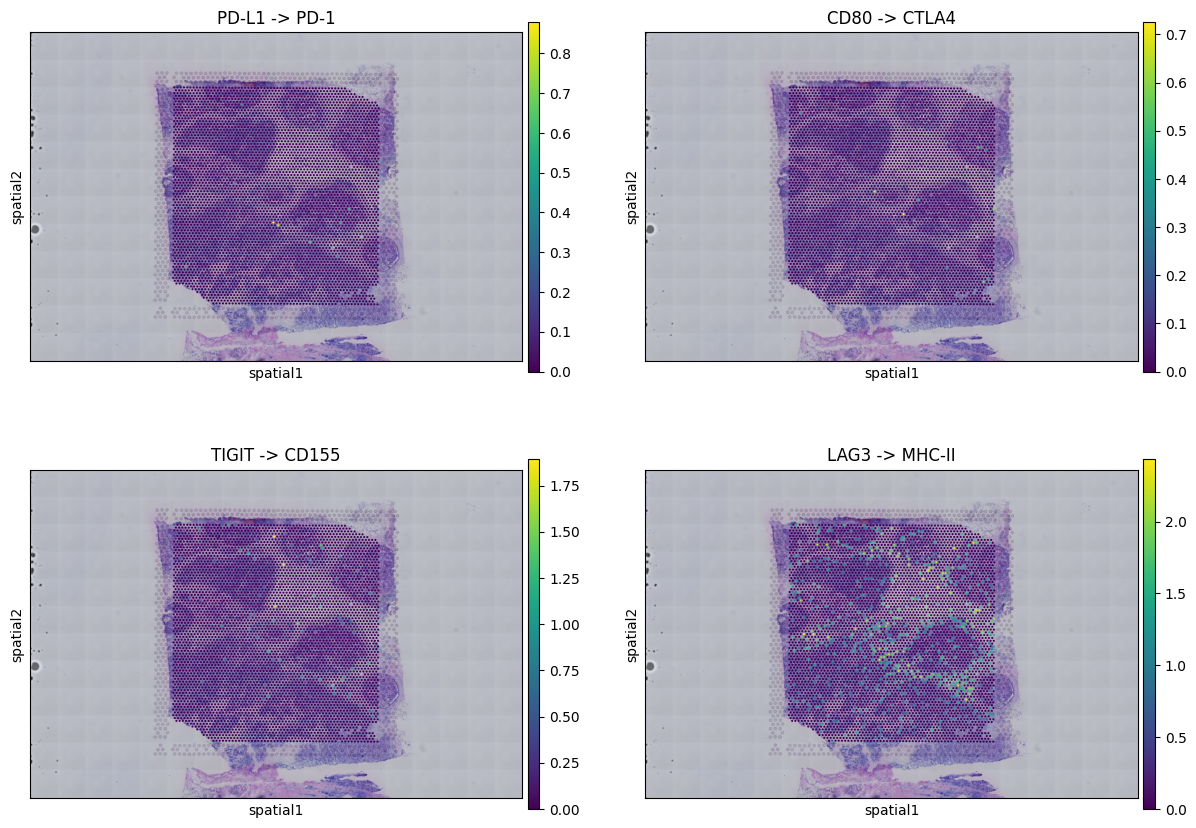

In [7]:
# CHECKPOINT AXIS SPATIAL MAP
# Visual proof of PD-L1/PD-1 location on tissue

checkpoint_pairs = [
    'PD-L1 -> PD-1',
    'CD80 -> CTLA4',
    'TIGIT -> CD155',
    'LAG3 -> MHC-II',
]
checkpoint_cols = [f'lr_{p}' for p in checkpoint_pairs
                   if f'lr_{p}' in adata.obs.columns]

prev_figdir = sc.settings.figdir
sc.settings.figdir = str(fig_cc_dir)

sq.pl.spatial_scatter(
    adata,
    color=checkpoint_cols,
    ncols=2,
    use_raw=False,
    title=checkpoint_pairs[:len(checkpoint_cols)],
    save='_03_checkpoint_spatial.png'
)

sc.settings.figdir = prev_figdir
print('Saved -> figures/cellcomm/03_checkpoint_spatial.png')
print('\nCheck if PD-L1/PD-1 overlaps with immune exclusion zone!')

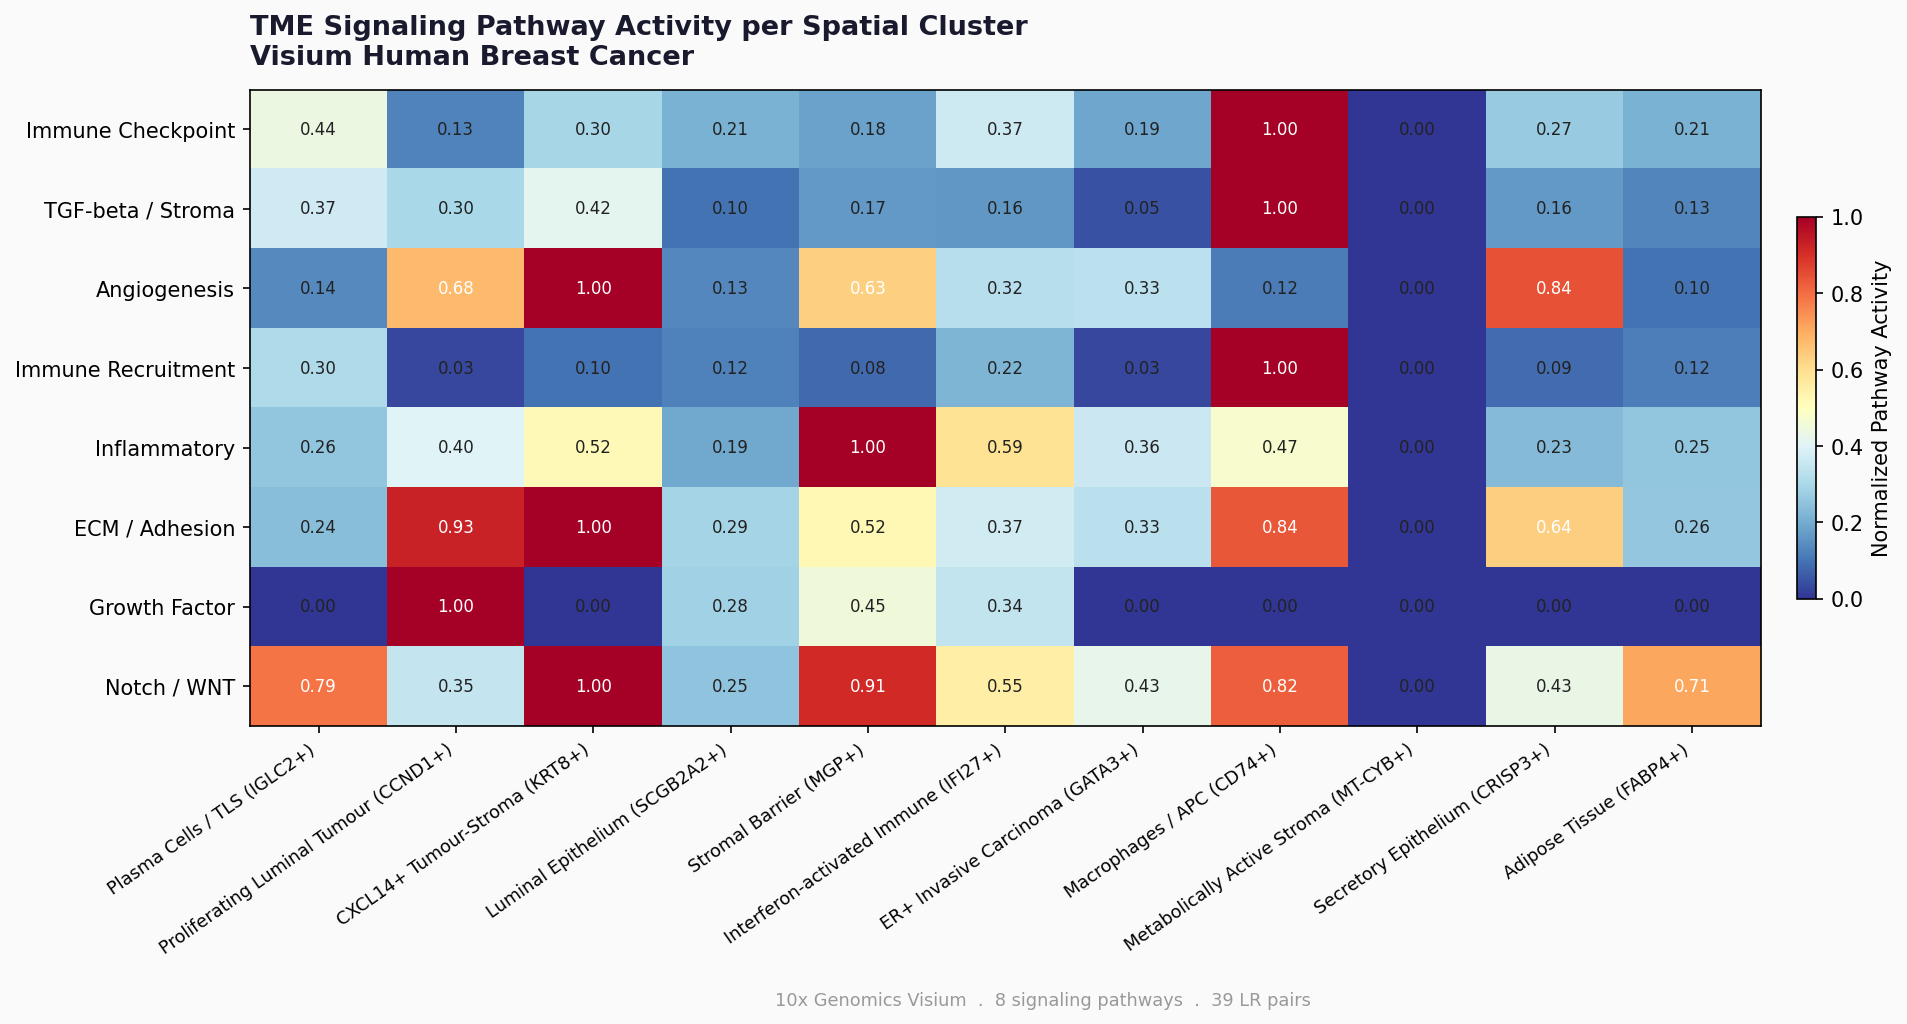

Saved -> C:\Users\mmsid\Documents\github\My Project\spatial_biology_project\figures\cellcomm\05_pathway_activity_pub.png

Pathway                Most Active Cluster
-------------------------------------------------------
  Immune Checkpoint    Macrophages / APC (CD74+)  (1.00)
  TGF-beta / Stroma    Macrophages / APC (CD74+)  (1.00)
  Angiogenesis         CXCL14+ Tumour-Stroma (KRT8+)  (1.00)
  Immune Recruitment   Macrophages / APC (CD74+)  (1.00)
  Inflammatory         Stromal Barrier (MGP+)  (1.00)
  ECM / Adhesion       CXCL14+ Tumour-Stroma (KRT8+)  (1.00)
  Growth Factor        Proliferating Luminal Tumour (CCND1+)  (1.00)
  Notch / WNT          CXCL14+ Tumour-Stroma (KRT8+)  (1.00)


In [8]:
# PATHWAY-LEVEL SUMMARY HEATMAP
# 8 pathways x 11 clusters — central finding figure

pathway_groups = {
    'Immune Checkpoint' : ['PD-L1 -> PD-1','CD80 -> CTLA4',
                            'TIGIT -> CD155','LAG3 -> MHC-II'],
    'TGF-beta / Stroma' : ['TGFb1 -> TGFBR1','TGFb1 -> TGFBR2',
                            'TGFb2 -> TGFBR2'],
    'Angiogenesis'      : ['VEGFA -> KDR','VEGFA -> FLT1',
                            'VEGFC -> FLT4'],
    'Immune Recruitment': ['CXCL9 -> CXCR3','CXCL10 -> CXCR3',
                            'CXCL12 -> CXCR4','CXCL13 -> CXCR5',
                            'CCL2 -> CCR2','CCL5 -> CCR5','CCL19 -> CCR7'],
    'Inflammatory'      : ['TNF -> TNFRSF1A','FASL -> FAS',
                            'IL6 -> IL6R','IL1B -> IL1R1','IFNG -> IFNGR1'],
    'ECM / Adhesion'    : ['FN1 -> ITGA5','FN1 -> ITGB1',
                            'COL1A1 -> ITGA1','POSTN -> ITGAV'],
    'Growth Factor'     : ['EGF -> EGFR','EREG -> EGFR','NRG1 -> ERBB3'],
    'Notch / WNT'       : ['JAG1 -> NOTCH1','JAG1 -> NOTCH2','WNT5A -> FZD1'],
}

pathway_scores = {}
for pathway, pairs in pathway_groups.items():
    cols = [f'lr_{p}' for p in pairs if f'lr_{p}' in adata.obs.columns]
    if cols:
        pathway_scores[pathway] = adata.obs.groupby('cell_type')[cols] \
                                           .mean().mean(axis=1)

pathway_df   = pd.DataFrame(pathway_scores)
pathway_norm = (pathway_df - pathway_df.min()) / \
               (pathway_df.max() - pathway_df.min() + 1e-9)

fig, ax = plt.subplots(figsize=(14, 7), dpi=150)
fig.patch.set_facecolor('#FAFAFA')

im = ax.imshow(pathway_norm.T.values, aspect='auto',
               cmap='RdYlBu_r', vmin=0, vmax=1)

ax.set_xticks(range(len(pathway_norm.index)))
ax.set_xticklabels(pathway_norm.index, rotation=35, ha='right', fontsize=8.5)
ax.set_yticks(range(len(pathway_norm.columns)))
ax.set_yticklabels(pathway_norm.columns, fontsize=10)

for i in range(len(pathway_norm.index)):
    for j in range(len(pathway_norm.columns)):
        val = pathway_norm.iloc[i, j]
        ax.text(i, j, f'{val:.2f}', ha='center', va='center', fontsize=8,
                color='white' if val > 0.6 else '#222222')

plt.colorbar(im, ax=ax, shrink=0.6, pad=0.02,
             label='Normalized Pathway Activity')

ax.set_title(
    'TME Signaling Pathway Activity per Spatial Cluster\n'
    'Visium Human Breast Cancer',
    fontsize=13, fontweight='bold', loc='left', color='#1a1a2e', pad=12
)
fig.suptitle(
    f'10x Genomics Visium  .  8 signaling pathways  .  {len(lr_pairs)} LR pairs',
    fontsize=8.5, color='#999999', y=0.01
)

plt.tight_layout(rect=[0, 0.02, 1, 1])
out = fig_cc_dir / '05_pathway_activity_pub.png'
plt.savefig(out, dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print(f'Saved -> {out}')

print(f'\n{"Pathway":<22} {"Most Active Cluster"}')
print('-' * 55)
for pathway in pathway_norm.columns:
    top_cluster = pathway_norm[pathway].idxmax()
    score       = pathway_norm[pathway].max()
    print(f'  {pathway:<20} {top_cluster}  ({score:.2f})')

In [9]:
# SQUIDPY LIGREC — STATISTICAL PERMUTATION TEST
# Validates LR interactions are not random
# 500 permutations per cluster pair

interactions = pd.DataFrame({
    'source': [v[0] for k, v in lr_pairs.items()
               if v[0] in adata.var_names and v[1] in adata.var_names],
    'target': [v[1] for k, v in lr_pairs.items()
               if v[0] in adata.var_names and v[1] in adata.var_names],
})

print(f'Testing {len(interactions)} LR pairs via permutation...')

sq.gr.ligrec(
    adata,
    n_perms=500,
    cluster_key='cell_type',
    interactions=interactions,
    use_raw=True,
    threshold=0.01,
    show_progress_bar=True,
)

print('Ligrec permutation test complete')
print("Results in adata.uns['cell_type_ligrec']")

Testing 39 LR pairs via permutation...
Running `500` permutations on `39` interactions and `121` cluster combinations using `1` core(s)


100%|██████████| 500/500 [00:32<00:00, 15.17permutation/s] 


Adding `adata.uns['cell_type_ligrec']`
Finish (0:00:36)
Ligrec permutation test complete
Results in adata.uns['cell_type_ligrec']


Found `29` significant interactions at level `0.001`
Saved -> figures/cellcomm/06_ligrec_tumor.png


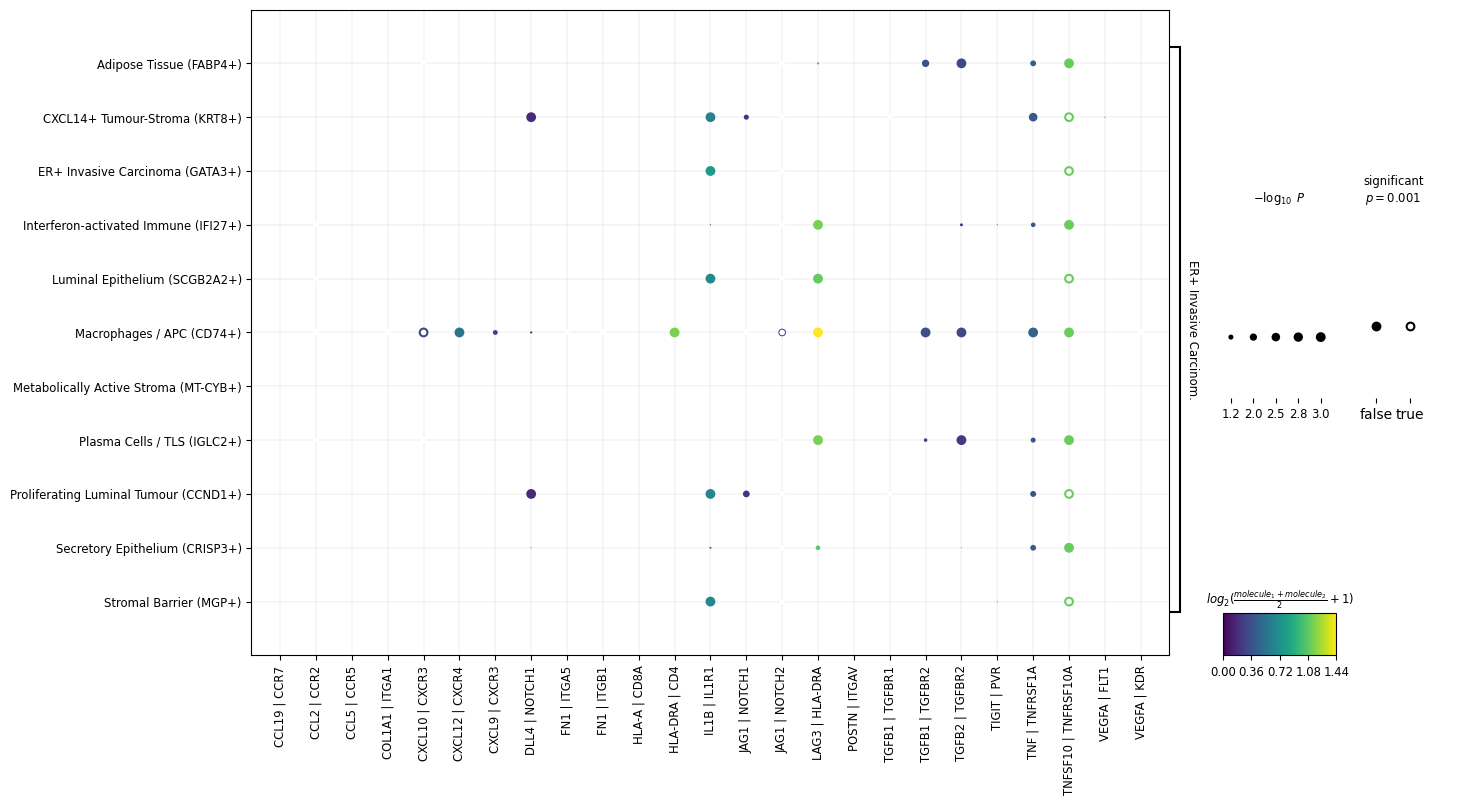

In [10]:
# LIGREC PLOT — significant interactions from tumour core

prev_figdir = sc.settings.figdir
sc.settings.figdir = str(fig_cc_dir)

tumor_cluster = 'ER+ Invasive Carcinoma (GATA3+)'

sq.pl.ligrec(
    adata,
    cluster_key='cell_type',
    source_groups=tumor_cluster,
    means_range=(0.1, np.inf),
    alpha=0.001,
    swap_axes=True,
    title='LR Interactions - Source: ER+ Invasive Carcinoma',
    figsize=(14, 8),
    save='_06_ligrec_tumor.png'
)

sc.settings.figdir = prev_figdir
print('Saved -> figures/cellcomm/06_ligrec_tumor.png')

In [12]:
# SAVE + SUMMARY

# Drop ligrec from uns — not HDF5-serializable
keys_to_drop = [k for k in adata.uns.keys() if 'ligrec' in k]
for k in keys_to_drop:
    del adata.uns[k]
    print(f'Dropped adata.uns["{k}"] (not HDF5-serializable)')

out_path = processed_dir / 'adata_cellcomm.h5ad'
adata.write_h5ad(out_path)

print(f'\nSaved   -> {out_path}')
print(f'Shape   : {adata.n_obs:,} spots x {adata.n_vars:,} genes')
print(f'Size    : {out_path.stat().st_size / 1e6:.1f} MB')

print('\n' + '='*55)
print('  NOTEBOOK 06 - CELL-CELL COMMUNICATION COMPLETE')
print('='*55)
print(f'  LR pairs tested    : {len(available)}')
print(f'  Pathways covered   : {len(pathway_groups)}')
print(f'  Key finding 1      : Checkpoint axis spatial map')
print(f'  Key finding 2      : TGF-beta stromal signaling')
print(f'  Key finding 3      : CXCL13->CXCR5 TLS recruitment')
print(f'  Figures saved      : figures/cellcomm/')
print(f'  Saved to           : data/processed/adata_cellcomm.h5ad')


Saved   -> C:\Users\mmsid\Documents\github\My Project\spatial_biology_project\data\processed\adata_cellcomm.h5ad
Shape   : 4,869 spots x 21,349 genes
Size    : 1185.2 MB

  NOTEBOOK 06 - CELL-CELL COMMUNICATION COMPLETE
  LR pairs tested    : 39
  Pathways covered   : 8
  Key finding 1      : Checkpoint axis spatial map
  Key finding 2      : TGF-beta stromal signaling
  Key finding 3      : CXCL13->CXCR5 TLS recruitment
  Figures saved      : figures/cellcomm/
  Saved to           : data/processed/adata_cellcomm.h5ad
